Os dados foram baixados do seguinte link disponibilizado no PDF do desafio -> https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?resource=download

In [236]:
#Importe dos dados

import pandas as pd

df = pd.read_csv("/data.csv")

In [237]:
#Verificando o tamanho da base e a dimencionalidade
df.shape

(569, 33)

In [239]:
#Verificando se alguma coluna possui dados nulos ou faltntes
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [240]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [241]:
#Todos os valores da Coluna Unnamed: 32 são nulos, portanto a coluna será excluída
df = df.drop("Unnamed: 32", axis=1)

In [242]:
#Removendo colunas que não são necessárias
df = df.drop("id", axis=1)

In [243]:
#Verificando se a coluna realmente foi excluída
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [244]:
#Verificando quais são os tipos de dados na base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [245]:
#Verificando quais valores existem para a única variável que é OBJECT
df["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


In [246]:
#Verificando a distribuição desses dados em %
df["diagnosis"].value_counts(normalize=True) * 100

,proportion
diagnosis,
B,62.741652
M,37.258348


In [247]:
#Transformando a variável vategórica em Numérica
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

In [248]:
#Verificando as estatísticas completas
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


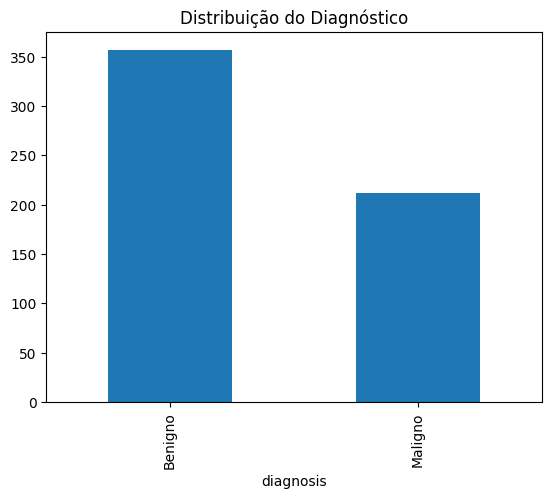

In [249]:
#Verificando a distribuição entre Diagnosticos positivos e negativos
import matplotlib.pyplot as plt
df["diagnosis"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["Benigno", "Maligno"])
plt.title("Distribuição do Diagnóstico")
plt.show()

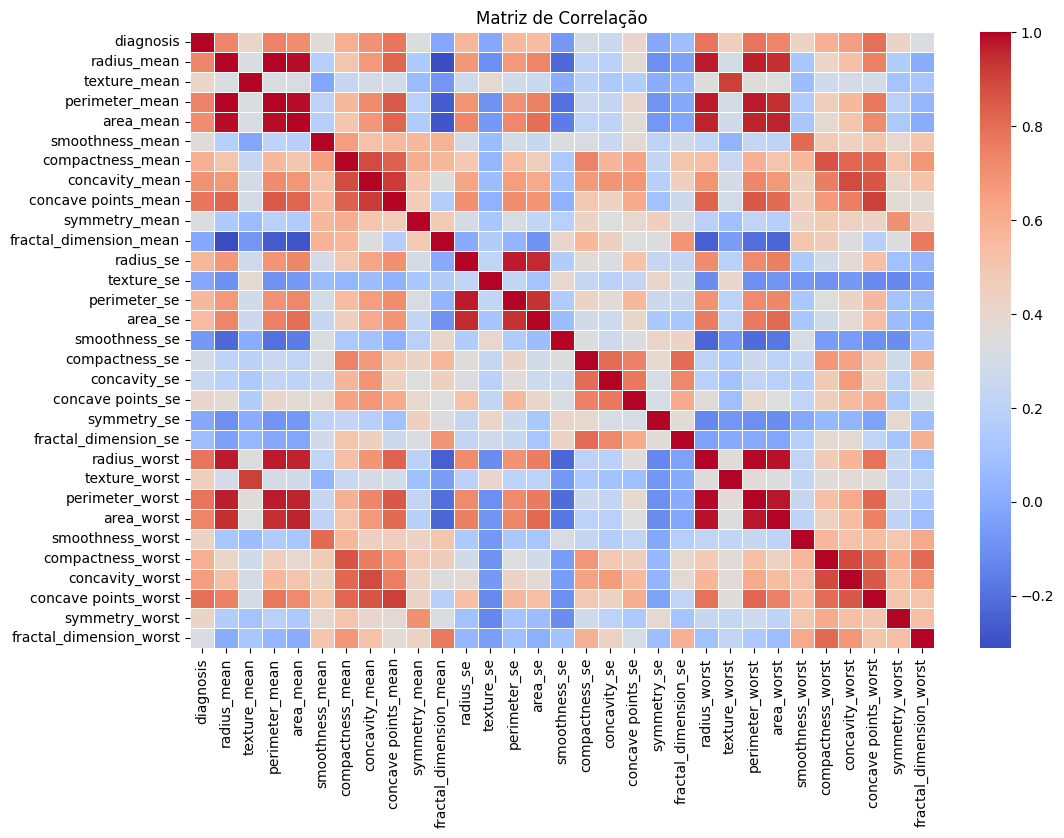

In [250]:
#Matriz de Correlação

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlação")
plt.show()


Na matriz de correlação, podemos observar uma correlação positiva (tons de vermelho escuro) entre características de tamanho, como radius, perimeter e area.

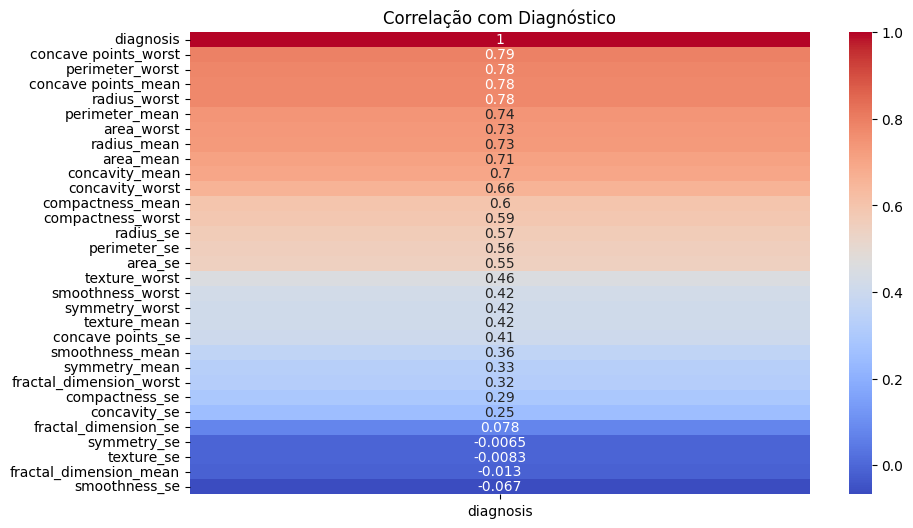

In [251]:
#Verificando a correlação das demais colunas dos dados com o Diagnóstico Final
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr[["diagnosis"]].sort_values(by="diagnosis", ascending=False),
            annot=True, cmap="coolwarm")
plt.title("Correlação com Diagnóstico")
plt.show()

Mesmo que, como a professora comentou na aula, que a correlção dos dados não necessáriamente significa causalidade, podemos observar no mapa da calor que as variáveis com maior correlação (> 0.70) com a variável diagnóstico (que no caso consiste na mais importante na análise desses dados) são as seguintes:


*   concave points_worst (0.79)
*   perimeter_worst (0.78)
*   Concave_points_mean (0,78)
*   radius_worst (0.78)
*   perimeter_mean (0.74)
*   area_worst (0.73)
*   radius_mena (0.73)
*   area_mean (0.71)









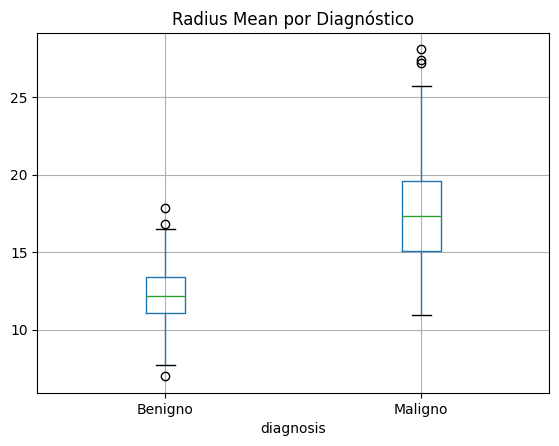

In [252]:
#Analisando a variável radius_mean
df.boxplot(column="radius_mean", by="diagnosis")
plt.xticks([1,2], ["Benigno", "Maligno"])
plt.title("Radius Mean por Diagnóstico")
plt.suptitle("")
plt.show()

os casos classificados como malignos, podemos observar que os valores de radius_mean tendem a ser maiores quando comparados aos casos benignos. Além disso, podemos perceber uma maior dispersão dos dados na classe maligna, indicando assim uma maior variabilidade desse atributo nesse grupo.

Nas duas classes (benigna e maligna), existem a presença de outliers, que são representados pelos pontos fora dos limites do boxplot, o que sugere a existência de alguns valores extremos nos dois tipos de diagnósticos.

Sendo assim, o atributo radius_mean apresenta um bom potencial de discriminação entre os diagnósticos, podendo ser considerado uma variável relevante para modelos de classificação.


<Axes: title={'center': 'area_mean'}, xlabel='diagnosis'>

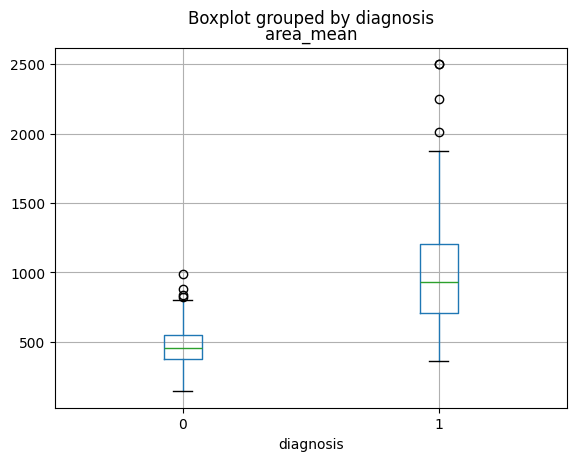

In [253]:
#Analisando a variável area_mean
df.boxplot(column="area_mean", by="diagnosis")

Analisando o gráfico, podemos verificar que a variável area_mean é  discriminante para o diagnóstico. Os diagnosticos do tipo 1 (Malígno) apresentam áreas médias maiores e com maior variação interna do que os do grupo 0 (Benígno). Os dois grupos também possuem a presença de outliers superiores.

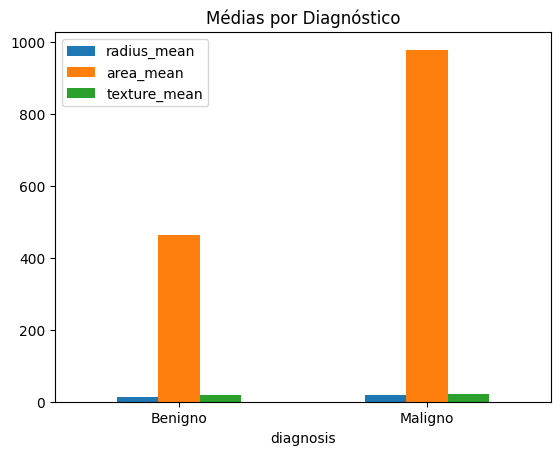

In [254]:
#Verificando o tamanho do tumor -> radius_mean
df.groupby("diagnosis")[["radius_mean", "area_mean", "texture_mean"]].mean().plot(kind="bar")
plt.xticks([0,1], ["Benigno", "Maligno"], rotation=0)
plt.title("Médias por Diagnóstico")
plt.show()

Confirmando o que foi visto no boxplot, a média da área dos tumores classificados como Maligno ( aprox. 980) é mais do que o dobro da média dos tumores Benignos (aprox. 460)

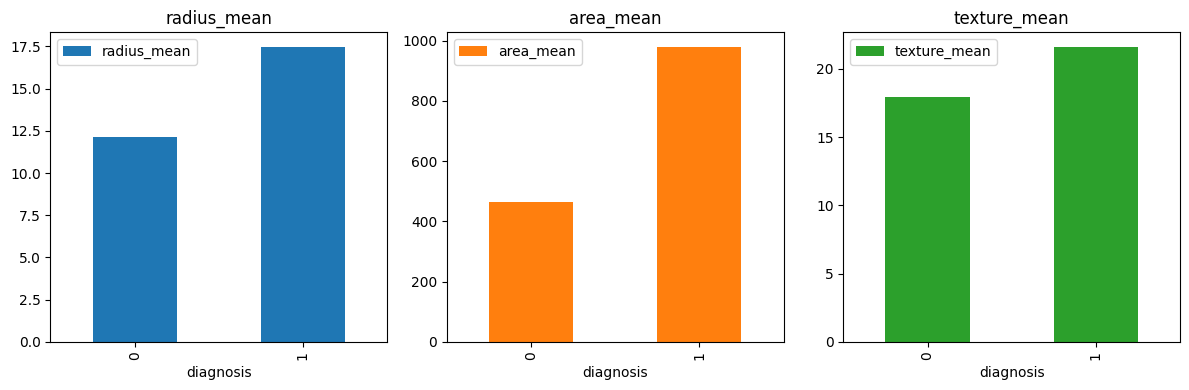

In [255]:
#Analisando de forma separada as 3 classes de médias
df.groupby("diagnosis")[["radius_mean", "area_mean", "texture_mean"]].mean().plot(kind="bar", subplots=True, layout=(1, 3), figsize=(12, 4))
plt.tight_layout()
plt.show()

A análise das médias nos permite observar que tumores malignos (1) são bem maiores e mais irregulares do que os benignos (0). A variável area_mean é o indicador mais impactante, dobrando de tamanho no diagnóstico maligno, e também há um aumento de 40% em radius_mean. A textura (texture_mean) também é maior no grupo maligno, embora apresente uma diferença menor (20%). Essas 3 classes de médias são características físicas e visuais dos tumores, e analisando podemos afimar que são discriminante para a separação das classes.

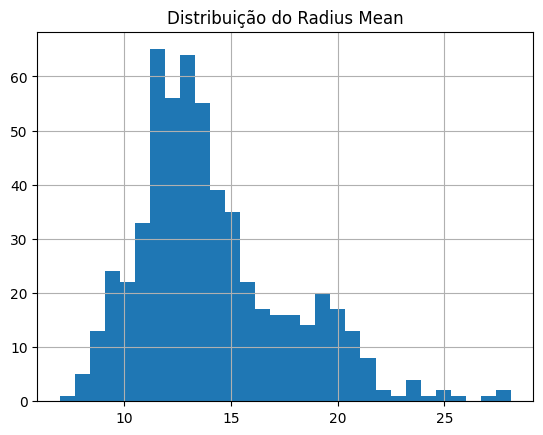

In [256]:
#Histograma para a análise do Radius Mean
df["radius_mean"].hist(bins=30)
plt.title("Distribuição do Radius Mean")
plt.show()

Existe uma maior concentração de tumores na faixa entre 11 e 14, o que sugere que raios menores são mais frequentes.


Modelos escolhidos para a classificação: Random Forest e Regressão Logística


In [257]:
from sklearn.preprocessing import StandardScaler

# Inicializa o padronizador, importante para a Regressão Logística
scaler = StandardScaler()

In [258]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Remoção da coluna alvo
X = df.drop(columns=["diagnosis"])

# Armazenando em y o alvo
y = df["diagnosis"]

# Separação da base entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Ajusta e transforma os dados de treino, e APENAS transforma os de teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train_scaled.shape[0]}")
print(f"Teste: {X_test_scaled.shape[0]}")

Treino: 455
Teste: 114


Foi adicionado a estratégia de amostragem estratificada (stratify=y), para que seja garantido que a proporção original de tumores benignos e malignos fosse mantida em ambas as partições.

In [262]:
# Inicialização da Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

# Treinamento da Random Forest com os dados escalonados
modelo_rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [263]:
#Utilizando o modelo para Predição
y_pred = modelo_rf.predict(X_test_scaled)

In [264]:
#Avaliando a acurácia do Modelo
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acuracia * 100:.2f}%\n")

Acurácia: 97.37%



Apesar da acurácia ter um valor excelente, para o contexto é necessário avaliar outras métricas. Abaixo está o relatório.

In [265]:
print(classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Olhando para o Recall (Sensibilidade) da Classe de Maligno (93%), que é a métrica mais importante do cenário pois ela mede a capacidade do modelo de encontrar as pacientes doentes, verificamos que temos o valor de 0.93 indica que de 42 pacientes com tumores malignos, o modelo identificou 39 e deixou passar 3 (Falsos Negativos).


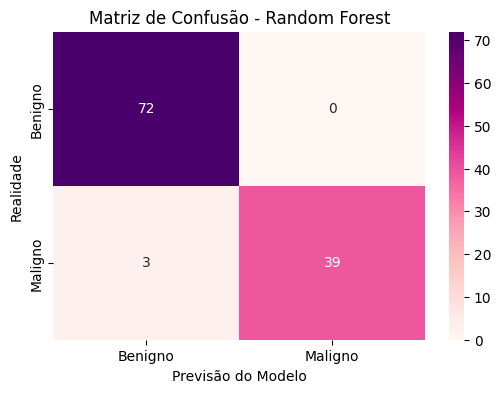

In [275]:
#Avaliando melhor falsos NEGATIVOS e falsos POSITIVOS com a Matriz de Confusão
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdPu",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)

plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

Analisando a matriz de confusão, podemos observar 3 falsos positivos, quando o modelo classificou como tumor benigno, mas no entanto consistia em 3 tumores malignos.

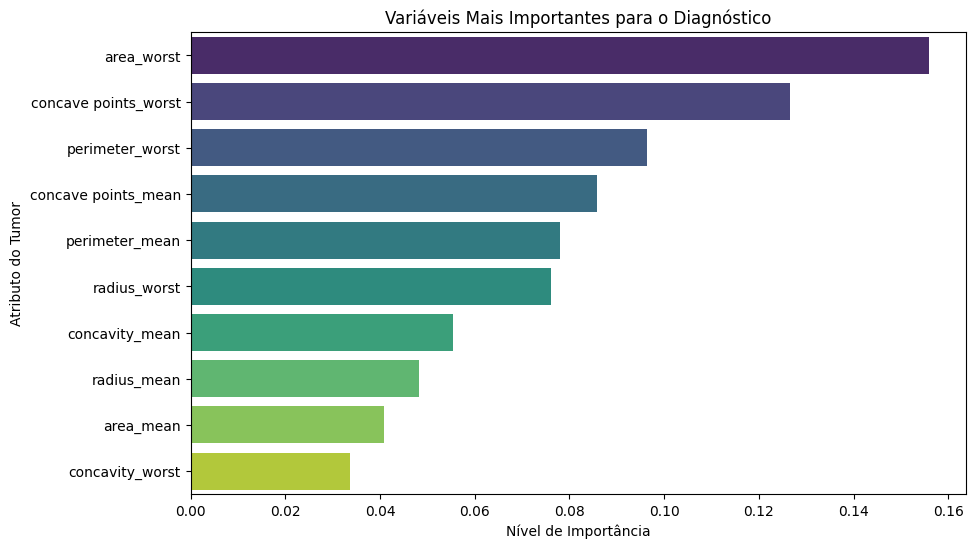

In [274]:
# Importância das Variáveis
importancias = modelo_rf.feature_importances_

df_importancia = pd.DataFrame({'Variável': X.columns, 'Importância': importancias})
df_importancia = df_importancia.sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=df_importancia.head(10), hue='Variável', legend=False, palette='viridis')

plt.title('Variáveis Mais Importantes para o Diagnóstico')
plt.xlabel('Nível de Importância')
plt.ylabel('Atributo do Tumor')
plt.show()

O Feature Importance mostra que a variável area_worst é o fator mais determinante para o modelo,com mais de 15% de impacto, ou seja, o extremo do nódulo é o principal sinal de malignidade. Nas métricas de contorno e irregularidade como concave points_worst e perimeter_worst, somam mais de 23% da tomada de decisão. Podemos dizer que o algoritmo priorizou as variáveis de pior cenário (_worst) em vez das médias (_mean), bouscando focar na região mais agressiva da lesão para garantir um diagnóstico preciso.

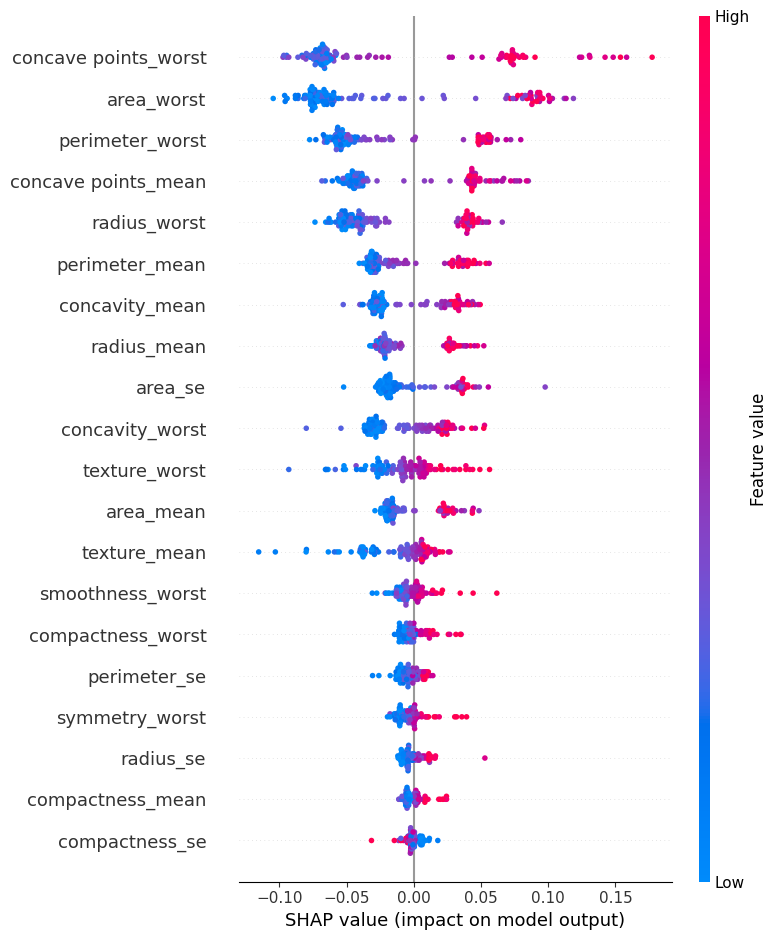

In [276]:
#Utilização da Técnica SHAP

import shap

explainer = shap.TreeExplainer(modelo_rf)
shap_values_obj = explainer(X_test_scaled)
shap.summary_plot(shap_values_obj[:, :, 1], X_test_scaled, feature_names=X.columns)

O gráfico SHAP indica que valores altos de características ligadas ao tamanho e à irregularidade do tumor, como já destacado e descutido antes, como concave points_worst e area_worst, possuem forte impacto positivo no SHAP value, empurrando a previsão na direção do diagnóstico Maligno.



Os valores baixos (pontos azuis) dessas mesmas variáveis agrupam-se à esquerda do eixo zero, correlacionando-se diretamente a previsões de tumores Benignos. Dessa forma, podemos notar que as variáveis associadas ao erro padrão (_se) mostram-se mais concentradas em torno do zero, indicando menor poder de decisão individual. Ou seja, podemos concluir que quanto maiores e mais côncavos forem os tumores, maior será o risco estimado de malignidade.


In [277]:
#Regressão Logística

from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
modelo_lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
#Predição
y_pred_lr = modelo_lr.predict(X_test_scaled)

In [ ]:
#Avaliação dos Resultados
acuracia_lr = accuracy_score(y_test, y_pred_lr)
print(f"Acurácia Regressão Logística: {acuracia_lr * 100:.2f}%\n")
print(classification_report(y_test, y_pred_lr, target_names=["Benigno", "Maligno"]))

Acurácia Regressão Logística: 97.37%

              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



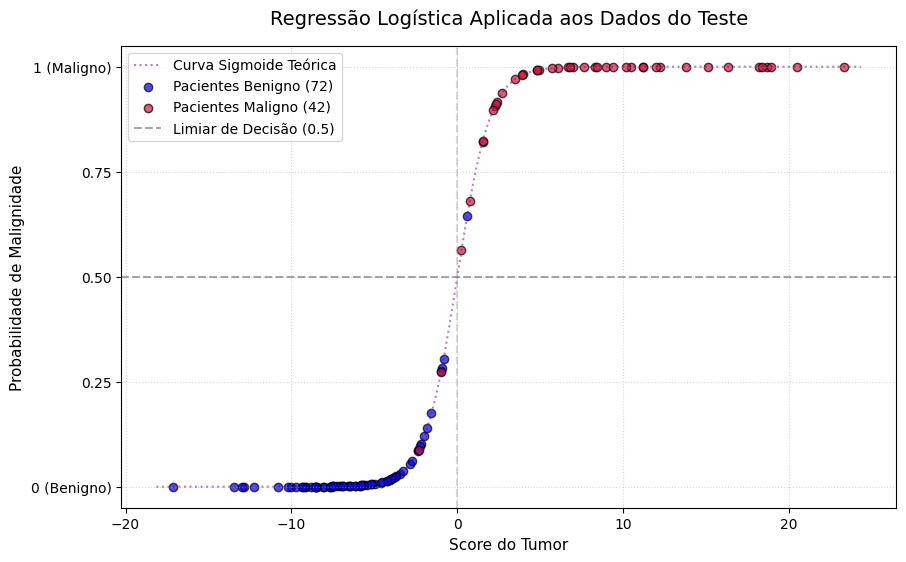

In [284]:

#Visualização dos resultados

#Combinação linear para as 114 pacientes do teste
scores = modelo_lr.decision_function(X_test_scaled)
probabilidades = modelo_lr.predict_proba(X_test_scaled)[:, 1]

#Gráfico
x_curva = np.linspace(scores.min() - 1, scores.max() + 1, 300)
y_curva = 1 / (1 + np.exp(-x_curva))
plt.figure(figsize=(10, 6))
plt.plot(x_curva, y_curva, color='purple', linestyle=':', alpha=0.5, label='Curva Sigmoide Teórica')

plt.scatter(scores[y_test == 0], probabilidades[y_test == 0],
            color='blue', alpha=0.7, edgecolors='k', label='Pacientes Benigno (72)')
plt.scatter(scores[y_test == 1], probabilidades[y_test == 1],
            color='crimson', alpha=0.7, edgecolors='k', label='Pacientes Maligno (42)')

# Linha do limiar de decisão de 0.5 (onde o modelo divide as classes)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Limiar de Decisão (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# Customização
plt.title('Regressão Logística Aplicada aos Dados do Teste', fontsize=14, pad=15)
plt.xlabel('Score do Tumor', fontsize=11)
plt.ylabel('Probabilidade de Malignidade', fontsize=11)
plt.yticks([0, 0.25, 0.5, 0.75, 1.0], ['0 (Benigno)', '0.25', '0.50', '0.75', '1 (Maligno)'])

plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

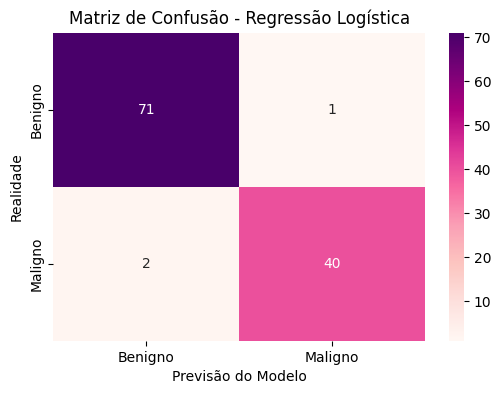

In [287]:
#Matriz de Confusão
plt.figure(figsize=(6, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="RdPu",
            xticklabels=["Benigno", "Maligno"],
            yticklabels=["Benigno", "Maligno"])
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

Analisando a matriz de confusão, podemos dizer que Para tumores benignos, o algoritmo demonstrou altíssima eficácia ao acertar 71 dos 72 casos reais, resultando em um recall de 99%. No cenário crítico de malignidade, o modelo minimizou riscos graves ao capturar com sucesso 40 dos 42 tumores reais (recall de 95%). A margem de erro limitou-se a apenas 2 falsos negativos e 1 falso positivo. A Regressão Logística é Mais Segura, uma vez que o objetivo principal é minimizar os Falsos Negativos. A Regressão Logística identificou 40 dos 42 casos malignos (Recall de 95.24%), enquanto a Random Forest identificou 39. Sendo assim, podemos dizer que a Regressão Logística foi estatisticamente superior no quesito segurança.

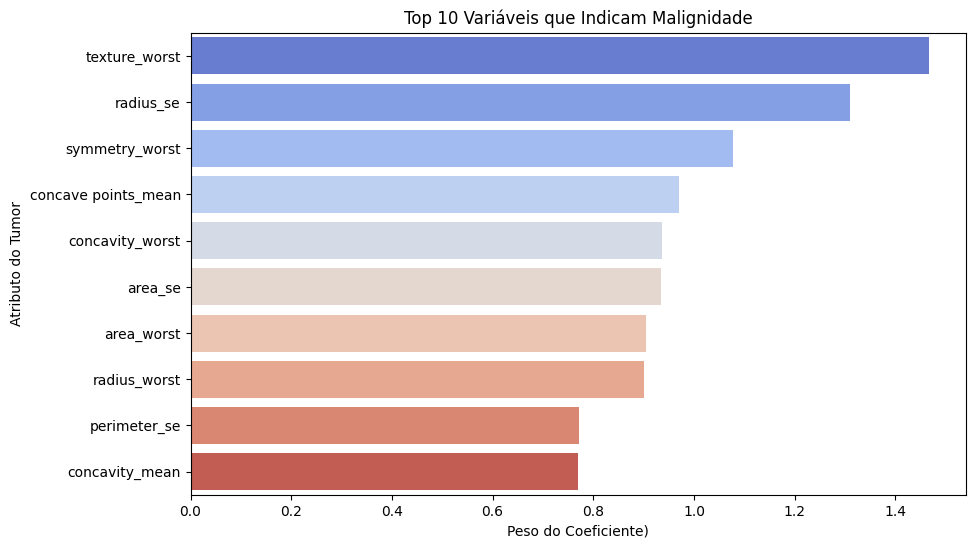

In [290]:
# Coleta dos coeficientes do modelo
coeficientes = modelo_lr.coef_[0]

# Ordenação do impacto das variáveis
df_coef = pd.DataFrame({'Variável': X.columns, 'Coeficiente': coeficientes})
df_coef = df_coef.sort_values(by='Coeficiente', ascending=False)

# 10 variáveis que mais empurram o diagnóstico para "Maligno"
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Variável', data=df_coef.head(10), hue='Variável', legend=False, palette='coolwarm')
plt.title('Top 10 Variáveis que Indicam Malignidade')
plt.xlabel('Peso do Coeficiente)')
plt.ylabel('Atributo do Tumor')
plt.show()

O gráfico de coeficientes da Regressão Logística nos mostra que a irregularidade e a variação estrutural do nódulo são os fatores mais determinantes para apontar a malignidade de um tumor. A variável texture_worst fica em primeiro lugar como o principal indicador de risco, seguida de perto por radius_se, evidenciando que uma textura muito áspera e alta oscilação no raio elevam drasticamente a probabilidade de câncer. Podemos notar também que há mais dos atributos do tipo _worst,  que prova que o modelo prioriza os piores cenários e as regiões mais agressivas da lesão em vez de médias gerais. Como todos os coeficientes são positivos, cada um desses dez fatores atua proporcionalmente, impulsionando o diagnóstico em direção à classe maligna.



Total de casos no teste: 114
Casos onde os modelos discordaram: 4



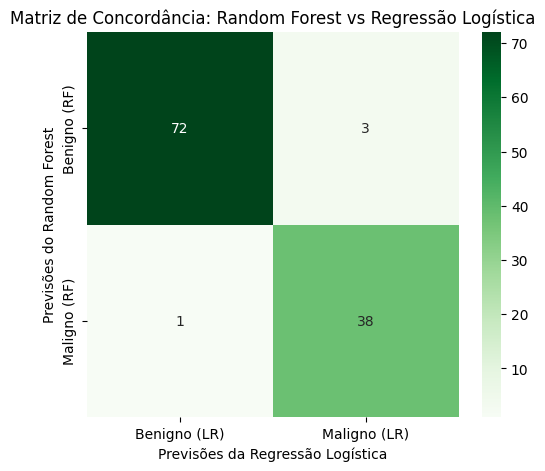

In [293]:
#MATRIZ DE CONCORDÂNCIA ENTRE OS MODELOS

# Gerar as probabilidades de previsão para a classe Maligno 1
prob_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]
prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

# DataFrame de Validação Cruzada
df_validacao = pd.DataFrame({
    'Realidade': y_test.values,
    'Pred_RandomForest': y_pred,
    'Prob_RandomForest': prob_rf,
    'Pred_RegLogistica': y_pred_lr,
    'Prob_RegLogistica': prob_lr
})

# Identificação das discondâncias
df_discordancia = df_validacao[df_validacao['Pred_RandomForest'] != df_validacao['Pred_RegLogistica']].copy()
print(f"Total de casos no teste: {len(df_validacao)}")
print(f"Casos onde os modelos discordaram: {len(df_discordancia)}\n")


# Matriz de Concordância entre os Modelos
plt.figure(figsize=(6, 5))
cm_modelos = confusion_matrix(df_validacao['Pred_RandomForest'], df_validacao['Pred_RegLogistica'])
sns.heatmap(cm_modelos, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Benigno (LR)", "Maligno (LR)"],
            yticklabels=["Benigno (RF)", "Maligno (RF)"])
plt.title("Matriz de Concordância: Random Forest vs Regressão Logística")
plt.xlabel("Previsões da Regressão Logística")
plt.ylabel("Previsões do Random Forest")
plt.show()

A matriz de concordância consiste em uma ferramenta para a validação de robustez. Os dois modelos utilizados empregam técnicas diferentes, a Regressão Logística utilizando a geometria linear e o Random Forest utilizando árvores de decisões, quando os dois modelos chegam na mesma conclusão sobre um caso, a confiabilidade do diagnóstico aumenta. A matriz serve como uma prova de que os modelos encontraram de fato um padrão biológico na base de dados, descartando a utilização de “chute” estatístico.